# Regression metrics

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [203]:
df = pd.read_csv("/content/placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package')

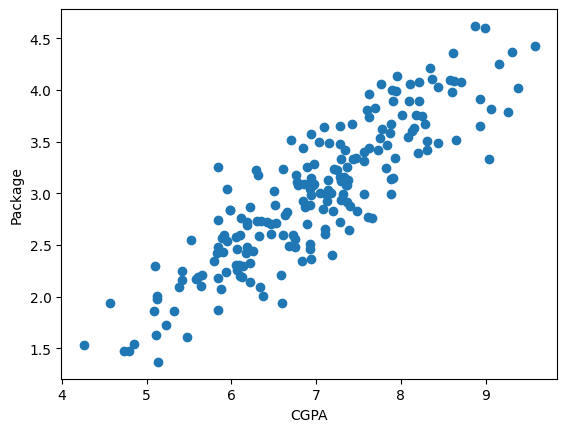

In [204]:
plt.scatter(df["cgpa"], df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package")

In [205]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [206]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


## split the data

In [207]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2,random_state=2)

## Train the model

In [208]:
from sklearn.linear_model import  LinearRegression

In [209]:
lr = LinearRegression()

In [210]:
lr.fit(X_train, y_train)

LinearRegression()

Text(0, 0.5, 'Package')

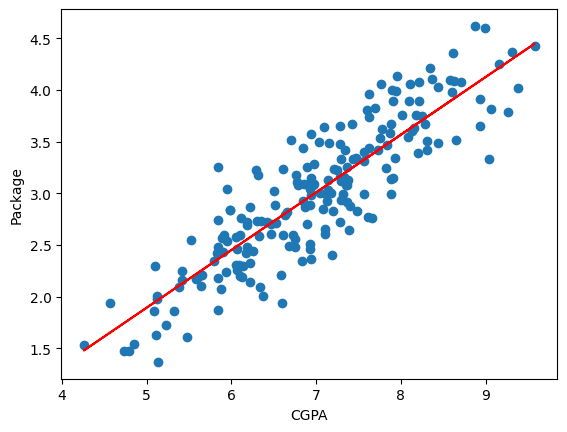

In [211]:
plt.scatter(df["cgpa"], df['package'])
plt.plot(X_train, lr.predict(X_train), color='r')
plt.xlabel("CGPA")
plt.ylabel("Package")

In [212]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [213]:
y_pred = lr.predict(X_test)
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [214]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

## Performance metrics

In [215]:
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

MAE: 0.2884710931878175
MSE: 0.12129235313495527
RMSE: 0.34827051717731616


In [216]:
# r2 score
score = r2_score(y_test, y_pred)
print(f"r2 score: {score}")

r2 score: 0.780730147510384


In [217]:
# adjusted r2 score

adj_r2_score = 1 - ((1 - score)*(len(X_test) - 1) ) / (len(X_test) - X_test.shape[1] - 1)
print(f"adjusted r2 score: {adj_r2_score}")

adjusted r2 score: 0.7749598882343415


## adding new features in dataset

In [218]:
new_df1= df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa', 'random_feature',"package"]]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.017621,3.26
1,5.12,0.574667,1.98
2,7.82,0.858671,3.25
3,7.42,0.338378,3.67
4,6.94,0.286166,3.57


Text(0, 0.5, 'Package')

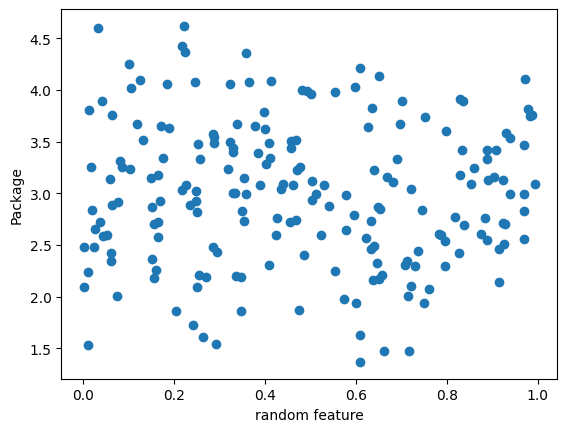

In [219]:
plt.scatter(new_df1["random_feature"], new_df1['package'])
plt.xlabel("random feature")
plt.ylabel("Package")

In [220]:
X = new_df1.iloc[:,0:-1]
y = new_df1.iloc[:,-1]

In [221]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2,random_state=2)

In [222]:
lr.fit(X_train, y_train)

LinearRegression()

In [223]:
y_pred = lr.predict(X_test)

In [224]:
# r2 score
score = r2_score(y_test, y_pred)
print(f"r2 score: {score}")

r2 score: 0.7814741678734439


In [225]:
# adjusted r2 score

adj_r2_score = 1 - ((1 - score)*(len(X_test) - 1) ) / (len(X_test) - X_test.shape[1] - 1)
print(f"adjusted r2 score: {adj_r2_score}")

adjusted r2 score: 0.769661960731468


In [226]:
new_df2= df.copy()
new_df2['iq'] = new_df2['package']  +( np.random.randint(-12,12,200) /10)

new_df2 = new_df2[['cgpa', 'iq',"package"]]
new_df2.head()

,cgpa,iq,package
0,6.89,3.96,3.26
1,5.12,1.98,1.98
2,7.82,3.85,3.25
3,7.42,2.57,3.67
4,6.94,4.27,3.57


Text(0, 0.5, 'Package')

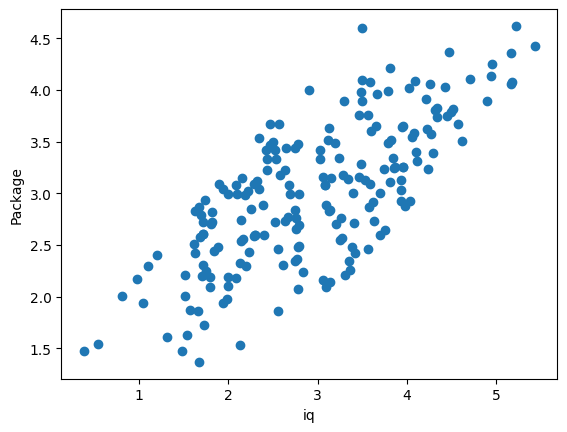

In [227]:
plt.scatter(new_df2["iq"], new_df2['package'])
plt.xlabel("iq")
plt.ylabel("Package")

In [228]:
X = new_df2.iloc[:,0:-1]
y = new_df2.iloc[:,-1]

In [229]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2,random_state=2)

In [230]:
lr.fit(X_train, y_train)

LinearRegression()

In [231]:
y_pred = lr.predict(X_test)

In [232]:
# r2 score
score = r2_score(y_test, y_pred)
print(f"r2 score: {score}")

r2 score: 0.8028424930685841


In [233]:
# adjusted r2 score

adj_r2_score = 1 - ((1 - score)*(len(X_test) - 1) ) / (len(X_test) - X_test.shape[1] - 1)
print(f"adjusted r2 score: {adj_r2_score}")

adjusted r2 score: 0.7921853305317508
